# Training Model (ResNet18)
## Setup and Imports

In [ ]:
import os
import pandas as pd
from pathlib import Path

csv_path = r"../data/processed/Labels_0.6.csv"
image_dir = r"../data/processed/preprocessed_glaucoma"

df = pd.read_csv(csv_path)

missing = []
for img_name in df['Image Name']:
    img_path = os.path.join(image_dir, img_name)
    if not os.path.exists(img_path):
        missing.append(img_name)

print("Missing images:", len(missing))
if len(missing) > 0:
    print(missing[:10])

OUTPUT_RESULT_DIR = Path("..") / "reports" / "results" / "training"
OUTPUT_FIGURE_DIR = Path("..") / "reports" / "figures" / "training"

# Ensure directories exist
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_RESULT_DIR.mkdir(parents=True, exist_ok=True)

C:\Users\Lee Pei En\AppData\Local\Temp\ipykernel_17872\3665662660.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Missing images: 0


## Data Inspection and Patient‑Level Splitting
Split train / val / test

In [2]:
import random
import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import train_test_split

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Load CSV
csv_path = r"../data/processed/Labels_0.6.csv"
df = pd.read_csv(csv_path)

df = df[['Image Name', 'Label_Binary']].dropna().copy()

# Extract Patient ID
df["Patient_ID"] = df["Image Name"].apply(lambda x: x.split("_")[0])

print("Total patients:", df["Patient_ID"].nunique())

# Create patient-level dataframe
patient_df = df.groupby("Patient_ID")["Label_Binary"].first().reset_index()

# Train / Temp split (70%)
train_patients, temp_patients = train_test_split(
    patient_df,
    test_size=0.3,
    stratify=patient_df["Label_Binary"],
    random_state=42
)

# Validation / Test split (15% / 15%)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5,  
    stratify=temp_patients["Label_Binary"],
    random_state=42
)

# Map patient split back to images
train_df = df[df["Patient_ID"].isin(train_patients["Patient_ID"])]
val_df = df[df["Patient_ID"].isin(val_patients["Patient_ID"])]
test_df = df[df["Patient_ID"].isin(test_patients["Patient_ID"])]

# Print dataset sizes
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

# Label distribution
print("\nTrain label distribution:")
print(train_df["Label_Binary"].value_counts())

print("\nValidation label distribution:")
print(val_df["Label_Binary"].value_counts())

print("\nTest label distribution:")
print(test_df["Label_Binary"].value_counts())

# Save splits
train_df.to_csv(r"../data/processed/train_split.csv", index=False)
val_df.to_csv(r"../data/processed/val_split.csv", index=False)
test_df.to_csv(r"../data/processed/test_split.csv", index=False)

print("\nSplits saved successfully.")

label_check = df.groupby("Patient_ID")["Label_Binary"].nunique()
mixed_label_patients = label_check[label_check > 1]

print("Patients with mixed labels:", len(mixed_label_patients))
print(mixed_label_patients.head())


# CHECK DATA LEAKAGE BETWEEN TRAIN / VAL / TEST
train_ids = set(train_df["Patient_ID"])
val_ids = set(val_df["Patient_ID"])
test_ids = set(test_df["Patient_ID"])

print("Train-Val overlap:", train_ids & val_ids)
print("Train-Test overlap:", train_ids & test_ids)
print("Val-Test overlap:", val_ids & test_ids)

print("\nDataset sizes:")
print("Train patients:", len(train_ids))
print("Val patients:", len(val_ids))
print("Test patients:", len(test_ids))

Total patients: 207
Train size: 300
Validation size: 61
Test size: 73

Train label distribution:
Label_Binary
1    215
0     85
Name: count, dtype: int64

Validation label distribution:
Label_Binary
1    44
0    17
Name: count, dtype: int64

Test label distribution:
Label_Binary
1    47
0    26
Name: count, dtype: int64

Splits saved successfully.
Patients with mixed labels: 0
Series([], Name: Label_Binary, dtype: int64)
Train-Val overlap: set()
Train-Test overlap: set()
Val-Test overlap: set()

Dataset sizes:
Train patients: 144
Val patients: 31
Test patients: 32


## Dataset Class and Transforms
### Create dataset class

In [3]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

class GlaucomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_name = self.dataframe.loc[idx, 'Image Name']
        label = self.dataframe.loc[idx, 'Label_Binary']

        image_path = os.path.join(self.image_dir, image_name)
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

### Define transforms

These images were already preprocessed to retinal crops and resized during the preprocessing notebook.
So the training augmentation should preserve anatomy and avoid a second random crop.

In [4]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.05, hue=0.01),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


## DataLoaders and Hyperparameters

In [5]:
from torch.utils.data import DataLoader

# Hyperparameters
BATCH_SIZE = 16
STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 15
STAGE1_LR = 5e-4
STAGE2_LR = 3e-5
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 5

image_dir = r"../data/processed/preprocessed_glaucoma"

train_dataset = GlaucomaDataset(train_df, image_dir, transform=train_transform)
val_dataset = GlaucomaDataset(val_df, image_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()
print("Using unweighted BCEWithLogitsLoss")


Train batches: 19
Val batches: 4
Using unweighted BCEWithLogitsLoss


## Model Definition (Two‑Stage Fine‑Tuning)

1. freeze backbone and train only the classifier head
2. unfreeze layer3 + layer4 + fc with a smaller learning rate


In [6]:
import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Stage 1: freeze full backbone
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

model = model.to(DEVICE)
print("Using device:", DEVICE)


Using device: cpu


## Loss Function and Optimizer

Monitor validation AUC instead of only validation loss.


In [7]:
import torch.optim as optim

def make_optimizer(model, lr):
    return optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

def make_scheduler(optimizer):
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=2
    )

optimizer = make_optimizer(model, STAGE1_LR)
scheduler = make_scheduler(optimizer)


## Training and Evaluation Functions

Track accuracy, F1, recall, precision, and ROC-AUC.


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def compute_binary_metrics(all_labels, all_probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in all_probs]
    metrics = {
        "acc": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
    }
    return metrics


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs).detach().cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().flatten())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_labels, all_probs, threshold=0.5)
    return epoch_loss, metrics


def evaluate_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().flatten())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_labels, all_probs, threshold=threshold)
    return epoch_loss, metrics


def find_best_threshold(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy().flatten())

    best_thresh = 0.5
    best_f1 = -1.0

    for t in np.arange(0.30, 0.71, 0.02):
        preds = [1 if p >= t else 0 for p in all_probs]
        f1 = f1_score(all_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = float(t)

    return best_thresh, best_f1


## Training model

Train the model in two stages and keep the checkpoint with the best validation AUC.


In [9]:
import copy

best_val_auc = -1.0
best_model_wts = copy.deepcopy(model.state_dict())
best_stage = None
patience_counter = 0

history = {
    "epoch": [],
    "stage": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_auc": [],
    "val_auc": [],
    "val_recall": [],
    "lr": [],
}


def run_training_stage(stage_name, epochs, optimizer, scheduler):
    global best_val_auc, best_model_wts, best_stage, patience_counter

    print(f"\n===== {stage_name} =====\n")
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_metrics = evaluate_one_epoch(model, val_loader, criterion, DEVICE, threshold=0.5)

        scheduler.step(val_metrics["auc"])
        current_lr = optimizer.param_groups[0]['lr']

        history["epoch"].append(len(history["epoch"]) + 1)
        history["stage"].append(stage_name)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])
        history["train_auc"].append(train_metrics["auc"])
        history["val_auc"].append(val_metrics["auc"])
        history["val_recall"].append(val_metrics["recall"])
        history["lr"].append(current_lr)

        print(f"{stage_name} Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Acc: {train_metrics['acc']:.4f} | F1: {train_metrics['f1']:.4f} | AUC: {train_metrics['auc']:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Acc: {val_metrics['acc']:.4f} | F1: {val_metrics['f1']:.4f} | Recall: {val_metrics['recall']:.4f} | AUC: {val_metrics['auc']:.4f}")
        print(f"Current LR: {current_lr:.8f}")

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            best_model_wts = copy.deepcopy(model.state_dict())
            best_stage = stage_name
            patience_counter = 0
            print("Validation AUC improved. Model checkpoint updated.\n")
        else:
            patience_counter += 1
            print(f"No AUC improvement. Early stop counter: {patience_counter}/{EARLY_STOP_PATIENCE}\n")
            if patience_counter >= EARLY_STOP_PATIENCE:
                print(f"Early stopping triggered for {stage_name}.\n")
                break


# Stage 1: train head only
run_training_stage("Stage 1 (fc only)", STAGE1_EPOCHS, optimizer, scheduler)

# Stage 2: unfreeze layer3 + layer4 + fc
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = make_optimizer(model, STAGE2_LR)
scheduler = make_scheduler(optimizer)
run_training_stage("Stage 2 (layer3 + layer4 + fc)", STAGE2_EPOCHS, optimizer, scheduler)

print(f"Best validation AUC: {best_val_auc:.4f} from {best_stage}")



===== Stage 1 (fc only) =====

Stage 1 (fc only) Epoch [1/5]
Train Loss: 0.6045 | Acc: 0.7067 | F1: 0.8167 | AUC: 0.5778
Val   Loss: 0.5431 | Acc: 0.7213 | F1: 0.8381 | Recall: 1.0000 | AUC: 0.7834
Current LR: 0.00050000
Validation AUC improved. Model checkpoint updated.

Stage 1 (fc only) Epoch [2/5]
Train Loss: 0.5497 | Acc: 0.7433 | F1: 0.8463 | AUC: 0.6796
Val   Loss: 0.4853 | Acc: 0.7377 | F1: 0.8462 | Recall: 1.0000 | AUC: 0.8877
Current LR: 0.00050000
Validation AUC improved. Model checkpoint updated.

Stage 1 (fc only) Epoch [3/5]
Train Loss: 0.4765 | Acc: 0.7767 | F1: 0.8595 | AUC: 0.8376
Val   Loss: 0.4384 | Acc: 0.7541 | F1: 0.8544 | Recall: 1.0000 | AUC: 0.9332
Current LR: 0.00050000
Validation AUC improved. Model checkpoint updated.

Stage 1 (fc only) Epoch [4/5]
Train Loss: 0.4427 | Acc: 0.8300 | F1: 0.8922 | AUC: 0.8640
Val   Loss: 0.4008 | Acc: 0.7869 | F1: 0.8713 | Recall: 1.0000 | AUC: 0.9545
Current LR: 0.00050000
Validation AUC improved. Model checkpoint updated.



## Load Best Model and Tune Threshold on Validation Set


In [10]:
model.load_state_dict(best_model_wts)
print("Best model loaded.")

best_thresh, best_val_f1 = find_best_threshold(model, val_loader, DEVICE)
print(f"Best validation threshold: {best_thresh:.2f}")
print(f"Best validation F1 at tuned threshold: {best_val_f1:.4f}")


Best model loaded.
Best validation threshold: 0.62
Best validation F1 at tuned threshold: 0.9885


## Save Checkpoint and Artifacts

We save the model weights, the best threshold, and other metadata. This checkpoint will be used in a separate test notebook.


In [11]:
import os
import json

training_artifact_dir = r"../models"
os.makedirs(training_artifact_dir, exist_ok=True)

checkpoint_path = os.path.join(
    training_artifact_dir,
    "augmented_glaucoma_resnet18.pth"
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "best_threshold": float(best_thresh),
    "best_val_f1_at_threshold": float(best_val_f1),
    "best_val_auc": float(best_val_auc),
    "best_stage": best_stage,
    "model_name": "resnet18",
    "image_dir": image_dir,
    "train_split_csv": r"../data/processed/train_split.csv",
    "val_split_csv": r"../data/processed/val_split.csv",
    "test_split_csv": r"../data/processed/test_split.csv",
    "batch_size": BATCH_SIZE,
}

torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")


Checkpoint saved to: ../models\augmented_glaucoma_resnet18——1.pth


In [13]:
print("Training notebook complete.")
print(f"Best validation AUC      : {best_val_auc:.4f}")
print(f"Best validation threshold: {best_thresh:.2f}")
print(f"Best validation F1       : {best_val_f1:.4f}")
print("Use the separate test notebook to evaluate on test_split.csv.")


Training notebook complete.
Best validation AUC      : 0.9973
Best validation threshold: 0.62
Best validation F1       : 0.9885
Use the separate test notebook to evaluate on test_split.csv.


## Plot training curves

These plots summarize the training-only workflow.


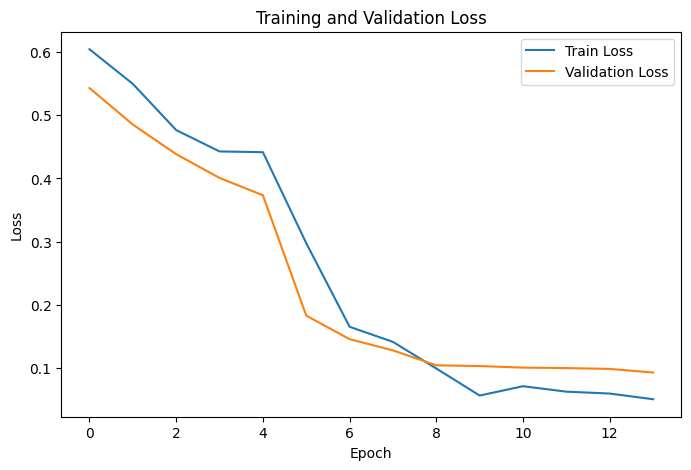

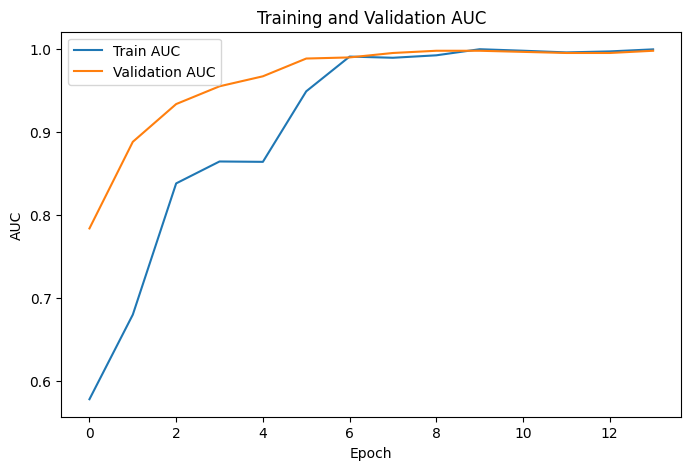

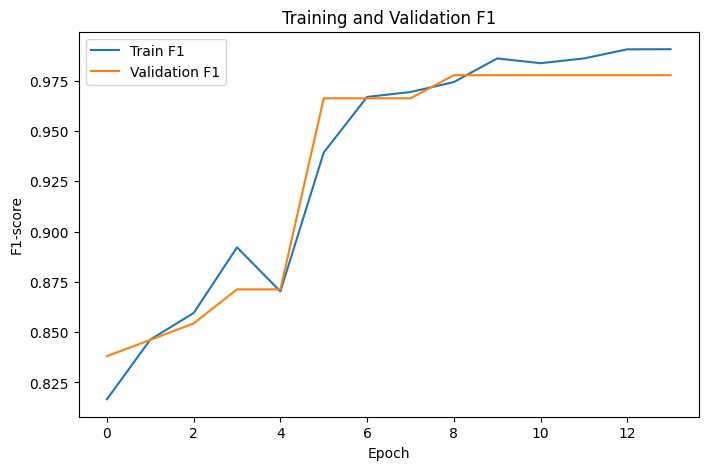

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
curves_dir = OUTPUT_FIGURE_DIR / "training_curves"
curves_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.savefig(curves_dir / "loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_auc"], label="Train AUC")
plt.plot(history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training and Validation AUC")
plt.legend()
plt.savefig(curves_dir / "auc.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_f1"], label="Train F1")
plt.plot(history["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training and Validation F1")
plt.legend()
plt.savefig(curves_dir / "f1_score.png", dpi=300, bbox_inches="tight")
plt.show()


The training curves show that the two-stage fine-tuning strategy was effective.

* **Loss (Figure 1):** During Stage 1 (epochs 1–5), both training and validation loss decrease clearly, showing that training the classifier head already improves performance. When Stage 2 begins (epoch 6, after layer3 and layer4 are unfrozen), both losses decrease further and validation loss reaches a much lower level, indicating that deeper fine-tuning improves feature learning.

* **AUC (Figure 2):** Validation AUC improves strongly in Stage 1, rising from about 0.78 to about 0.97, then increases further in Stage 2 to a peak of **0.9973**. This suggests that Stage 1 provides a strong baseline, while Stage 2 refines the model for better class separation.

* **F1-score (Figure 3):** Validation F1 also improves after Stage 2 and reaches a best value of **0.9885** with an optimal threshold of **0.62**, showing that threshold tuning improves classification balance beyond the default 0.5 cutoff.

Overall, these results suggest that classifier-head training provides useful early improvement, while deeper fine-tuning is important for achieving the best performance.

## Risk Scoring Mechanisms
### Confidence Scores and Risk Bins

We compute the raw sigmoid probabilities on the validation set and assign risk categories (low, moderate, high) based on the probability. This helps interpret the model's confidence.

In [ ]:
# CONFIDENCE SCORES + RISK BINS
import os
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss, f1_score

def collect_probs_labels(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()

            all_probs.extend(probs.tolist())
            all_labels.extend(labels.numpy().tolist())

    return np.array(all_labels, dtype=int), np.array(all_probs, dtype=float)

def tune_threshold_from_probs(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    best_t = 0.50
    best_f1_local = -1.0

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1_local:
            best_f1_local = score
            best_t = float(t)

    return best_t, float(best_f1_local)

def risk_category(p):
    if p < 0.30:
        return "Low Risk"
    elif p < 0.70:
        return "Moderate Risk"
    return "High Risk"

# Collect validation probabilities from the original model
val_labels_conf, val_probs_raw = collect_probs_labels(model, val_loader, DEVICE)

# Tune threshold on original sigmoid probabilities
best_thresh_confidence, best_val_f1_confidence = tune_threshold_from_probs(
    val_labels_conf, val_probs_raw
)

# Confidence diagnostic
raw_brier = brier_score_loss(val_labels_conf, val_probs_raw)

# Build confidence / risk table
risk_df = pd.DataFrame({
    "label": val_labels_conf,
    "probability": val_probs_raw,
})
risk_df["risk_group"] = risk_df["probability"].apply(risk_category)

# Save risk preview table
risk_preview_path = os.path.join(
    training_artifact_dir,
    "augmented_glaucoma_resnet18_val_risk_preview.csv"
)
risk_df.to_csv(risk_preview_path, index=False)

# Update checkpoint with confidence / risk metadata
checkpoint["best_threshold_confidence"] = float(best_thresh_confidence)
checkpoint["best_val_f1_confidence"] = float(best_val_f1_confidence)
checkpoint["val_brier_raw"] = float(raw_brier)
checkpoint["risk_preview_path"] = risk_preview_path
torch.save(checkpoint, checkpoint_path)

print("Confidence / risk preview saved.")
print(f"Risk preview CSV          : {risk_preview_path}")
print(f"Raw validation Brier      : {raw_brier:.4f}")
print(f"Best threshold (raw)      : {best_thresh_confidence:.2f}")
print(f"Best validation F1 (raw)  : {best_val_f1_confidence:.4f}")

print("\nValidation risk group counts:")
print(risk_df["risk_group"].value_counts())

Confidence / risk preview saved.
Risk preview CSV          : ../models\augmented_glaucoma_resnet18_val_risk_preview.csv
Raw validation Brier      : 0.0055
Best threshold (raw)      : 0.13
Best validation F1 (raw)  : 1.0000

Validation risk group counts:
risk_group
High Risk        43
Low Risk         17
Moderate Risk     1
Name: count, dtype: int64


### Confidence Diagnostic Plots

This plot checks how the raw sigmoid probabilities compare with observed validation outcomes. It is diagnostic only and does not change training or the saved model weights.

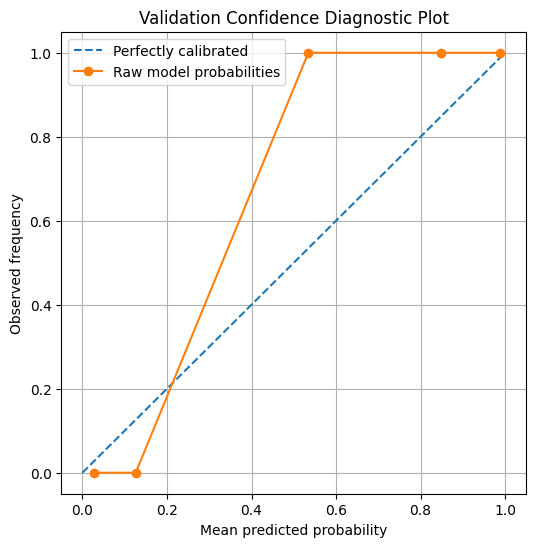

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true_raw, prob_pred_raw = calibration_curve(
    val_labels_conf,
    val_probs_raw,
    n_bins=8,
    strategy="uniform"
)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Raw model probabilities")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Validation Confidence Diagnostic Plot")
plt.legend()
plt.grid(True)
plt.savefig(OUTPUT_FIGURE_DIR / "confidence_diagnostic.png", dpi=300, bbox_inches="tight")
plt.show()

* The calibration curve shows small deviations from the diagonal, particularly in the mid-probability region, suggesting mild miscalibration in some ranges, although overall calibration remains good.

* The **Brier score of 0.0055** is very low, indicating that the predicted probabilities are generally well aligned with the observed outcomes.

* The risk distribution (**43 high-risk, 17 low-risk, 1 moderate-risk**) suggests that the model often produces confident predictions, which is consistent with its high discriminative performance.

* A very low threshold (**0.13**) can produce perfect validation F1 in this diagnostic analysis, but this may be optimistic because the validation set is relatively small.

## 5‑Fold Cross‑Validation
To assess the robustness and stability of our model, we perform 5‑fold patient‑level cross‑validation on the entire dataset. This gives us a distribution of performance metrics.

In [15]:
from sklearn.model_selection import GroupKFold

# 5-FOLD CROSS VALIDATION (PATIENT-LEVEL) FOR MODIFIED NOTEBOOK

import copy
from torch.utils.data import DataLoader
from torchvision import models
import torch.nn as nn
import torch.optim as optim

gkf = GroupKFold(n_splits=5)

fold_results = []
all_fold_histories = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df, df["Label_Binary"], groups=df["Patient_ID"]), start=1
):
    print(f"\n{'='*30}")
    print(f"FOLD {fold}")
    print(f"{'='*30}")

    # Split dataframe
    train_df_fold = df.iloc[train_idx].reset_index(drop=True)
    val_df_fold = df.iloc[val_idx].reset_index(drop=True)

    print("Train images   :", len(train_df_fold))
    print("Val images     :", len(val_df_fold))
    print("Train patients :", train_df_fold["Patient_ID"].nunique())
    print("Val patients   :", val_df_fold["Patient_ID"].nunique())

    # Datasets
    train_dataset_fold = GlaucomaDataset(train_df_fold, image_dir, transform=train_transform)
    val_dataset_fold = GlaucomaDataset(val_df_fold, image_dir, transform=val_test_transform)

    # Dataloaders
    train_loader_fold = DataLoader(
        train_dataset_fold,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0
    )

    val_loader_fold = DataLoader(
        val_dataset_fold,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    # Fresh model for each fold
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Stage 1: freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 1)
    )

    model = model.to(DEVICE)
    # Loss for this fold
    criterion = nn.BCEWithLogitsLoss()

    def make_optimizer_local(model, lr):
        return optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr,
            weight_decay=WEIGHT_DECAY
        )

    def make_scheduler_local(optimizer):
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=2
        )

    best_val_auc = -1.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    best_stage = None

    history = {
        "epoch": [],
        "stage": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
        "train_auc": [],
        "val_auc": [],
        "val_recall": [],
        "lr": [],
    }

    def run_training_stage_fold(stage_name, epochs, optimizer, scheduler):
        nonlocal_best = {"stop": False}
        nonlocal_patience = {"count": 0}

        return_best_auc = None
        return_best_wts = None
        return_best_stage = None

        global_best_auc = None  # placeholder to keep structure clear

        # Use outer variables
        nonlocal_vars = {
            "best_val_auc": None,
            "best_model_wts": None,
            "best_stage": None
        }

        nonlocal_vars["best_val_auc"] = best_val_auc
        nonlocal_vars["best_model_wts"] = best_model_wts
        nonlocal_vars["best_stage"] = best_stage

        for epoch in range(epochs):
            train_loss, train_metrics = train_one_epoch(model, train_loader_fold, criterion, optimizer, DEVICE)
            val_loss, val_metrics = evaluate_one_epoch(model, val_loader_fold, criterion, DEVICE, threshold=0.5)

            scheduler.step(val_metrics["auc"])
            current_lr = optimizer.param_groups[0]["lr"]

            history["epoch"].append(len(history["epoch"]) + 1)
            history["stage"].append(stage_name)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_metrics["acc"])
            history["val_acc"].append(val_metrics["acc"])
            history["train_f1"].append(train_metrics["f1"])
            history["val_f1"].append(val_metrics["f1"])
            history["train_auc"].append(train_metrics["auc"])
            history["val_auc"].append(val_metrics["auc"])
            history["val_recall"].append(val_metrics["recall"])
            history["lr"].append(current_lr)

            print(
                f"{stage_name} | Epoch [{epoch+1}/{epochs}] | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                f"Train AUC: {train_metrics['auc']:.4f} | Val AUC: {val_metrics['auc']:.4f} | "
                f"Val F1: {val_metrics['f1']:.4f} | LR: {current_lr:.6f}"
            )

            if val_metrics["auc"] > nonlocal_vars["best_val_auc"]:
                nonlocal_vars["best_val_auc"] = val_metrics["auc"]
                nonlocal_vars["best_model_wts"] = copy.deepcopy(model.state_dict())
                nonlocal_vars["best_stage"] = stage_name
                nonlocal_patience["count"] = 0
            else:
                nonlocal_patience["count"] += 1

            if nonlocal_patience["count"] >= EARLY_STOP_PATIENCE:
                print(f"Early stopping triggered during {stage_name}.")
                nonlocal_best["stop"] = True
                break

        return (
            nonlocal_vars["best_val_auc"],
            nonlocal_vars["best_model_wts"],
            nonlocal_vars["best_stage"],
            nonlocal_best["stop"]
        )

    # ---------------- Stage 1 ----------------
    print("\n===== STAGE 1: Train classifier head =====")
    optimizer = make_optimizer_local(model, STAGE1_LR)
    scheduler = make_scheduler_local(optimizer)

    best_val_auc, best_model_wts, best_stage, stop_now = run_training_stage_fold(
        "Stage 1", STAGE1_EPOCHS, optimizer, scheduler
    )

    # ---------------- Stage 2 ----------------
    if not stop_now:
        print("\n===== STAGE 2: Fine-tune full model =====")
        for param in model.parameters():
            param.requires_grad = True

        optimizer = make_optimizer_local(model, STAGE2_LR)
        scheduler = make_scheduler_local(optimizer)

        best_val_auc, best_model_wts, best_stage, _ = run_training_stage_fold(
            "Stage 2", STAGE2_EPOCHS, optimizer, scheduler
        )

    # Load best model for this fold
    model.load_state_dict(best_model_wts)
    print(f"Best model loaded from {best_stage} with Val AUC = {best_val_auc:.4f}")

    # Tune threshold on fold validation set
    best_thresh, best_val_f1 = find_best_threshold(model, val_loader_fold, DEVICE)
    print(f"Best threshold for fold {fold}: {best_thresh:.2f}")
    print(f"Best validation F1 at tuned threshold: {best_val_f1:.4f}")

    # Final evaluation on fold validation set
    val_loss, val_metrics = evaluate_one_epoch(
        model, val_loader_fold, criterion, DEVICE, threshold=best_thresh
    )

    print("\nFold Final Results")
    print(f"Threshold     : {best_thresh:.2f}")
    print(f"Accuracy      : {val_metrics['acc']:.4f}")
    print(f"Precision     : {val_metrics['precision']:.4f}")
    print(f"Recall        : {val_metrics['recall']:.4f}")
    print(f"F1-score      : {val_metrics['f1']:.4f}")
    print(f"ROC-AUC       : {val_metrics['auc']:.4f}")

    fold_results.append({
        "fold": fold,
        "train_images": len(train_df_fold),
        "val_images": len(val_df_fold),
        "train_patients": train_df_fold["Patient_ID"].nunique(),
        "val_patients": val_df_fold["Patient_ID"].nunique(),
        "best_stage": best_stage,
        "best_threshold": best_thresh,
        "accuracy": val_metrics["acc"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "auc": val_metrics["auc"]
    })

    all_fold_histories.append(history)

# ============================================================
# SHOW FINAL 5-FOLD RESULTS
# ============================================================

fold_results_df = pd.DataFrame(fold_results)
display(fold_results_df)

print("\n================ 5-FOLD SUMMARY ================")
print(f"Mean Accuracy : {fold_results_df['accuracy'].mean():.4f} ± {fold_results_df['accuracy'].std():.4f}")
print(f"Mean Precision: {fold_results_df['precision'].mean():.4f} ± {fold_results_df['precision'].std():.4f}")
print(f"Mean Recall   : {fold_results_df['recall'].mean():.4f} ± {fold_results_df['recall'].std():.4f}")
print(f"Mean F1-score : {fold_results_df['f1'].mean():.4f} ± {fold_results_df['f1'].std():.4f}")
print(f"Mean ROC-AUC  : {fold_results_df['auc'].mean():.4f} ± {fold_results_df['auc'].std():.4f}")


FOLD 1
Train images   : 347
Val images     : 87
Train patients : 167
Val patients   : 40

===== STAGE 1: Train classifier head =====
Stage 1 | Epoch [1/5] | Train Loss: 0.6925 | Val Loss: 0.5286 | Train AUC: 0.5029 | Val AUC: 0.6000 | Val F1: 0.8758 | LR: 0.000500
Stage 1 | Epoch [2/5] | Train Loss: 0.5649 | Val Loss: 0.4774 | Train AUC: 0.7187 | Val AUC: 0.8418 | Val F1: 0.8859 | LR: 0.000500
Stage 1 | Epoch [3/5] | Train Loss: 0.5136 | Val Loss: 0.4111 | Train AUC: 0.8085 | Val AUC: 0.9000 | Val F1: 0.8933 | LR: 0.000500
Stage 1 | Epoch [4/5] | Train Loss: 0.4563 | Val Loss: 0.3749 | Train AUC: 0.8784 | Val AUC: 0.9209 | Val F1: 0.9241 | LR: 0.000500
Stage 1 | Epoch [5/5] | Train Loss: 0.3982 | Val Loss: 0.3379 | Train AUC: 0.9365 | Val AUC: 0.9433 | Val F1: 0.9371 | LR: 0.000500

===== STAGE 2: Fine-tune full model =====
Stage 2 | Epoch [1/15] | Train Loss: 0.2727 | Val Loss: 0.1696 | Train AUC: 0.9661 | Val AUC: 0.9672 | Val F1: 0.9630 | LR: 0.000030
Stage 2 | Epoch [2/15] | Train

,fold,train_images,val_images,train_patients,val_patients,best_stage,best_threshold,accuracy,precision,recall,f1,auc
0,1,347,87,167,40,Stage 2,0.30,0.977011,0.971014,1.0,0.985294,0.987313
1,2,347,87,165,42,Stage 2,0.62,0.988506,0.984127,1.0,0.992000,0.998710
2,3,347,87,165,42,Stage 2,0.64,0.977011,0.967213,1.0,0.983333,0.996368
3,4,347,87,165,42,Stage 2,0.38,0.988506,0.983333,1.0,0.991597,0.999395
4,5,348,86,166,41,Stage 2,0.30,0.976744,0.967213,1.0,0.983333,0.996234



================ 5-FOLD SUMMARY ================
Mean Accuracy : 0.9816 ± 0.0063
Mean Precision: 0.9746 ± 0.0085
Mean Recall   : 1.0000 ± 0.0000
Mean F1-score : 0.9871 ± 0.0044
Mean ROC-AUC  : 0.9956 ± 0.0048


### Save the 5-fold results

In [16]:
import os
import pickle
import shutil

# delete the resnet18_cache folder and re‑run the 5‑fold CV chunk:
if os.path.exists("resnet18_cache"):
    shutil.rmtree("resnet18_cache")
    print("Cache cleared.")

cache_folder = "resnet18_cache"
os.makedirs(cache_folder, exist_ok=True)

fold_results_df.to_csv(os.path.join(cache_folder, "fold_results.csv"), index=False)
with open(os.path.join(cache_folder, "fold_histories.pkl"), "wb") as f:
    pickle.dump(all_fold_histories, f)

print(f"5‑fold results saved to {cache_folder}.")

5‑fold results saved to resnet18_cache.


### Add a new loading chunk

In [17]:
import os
import pandas as pd
import pickle

cache_folder = "resnet18_cache"
results_csv = os.path.join(cache_folder, "fold_results.csv")
histories_pkl = os.path.join(cache_folder, "fold_histories.pkl")

if os.path.exists(results_csv) and os.path.exists(histories_pkl):
    fold_results_df = pd.read_csv(results_csv)
    with open(histories_pkl, "rb") as f:
        all_fold_histories = pickle.load(f)
    print(f"Loaded cached 5‑fold results from {cache_folder}.")
else:
    print(f"Cache not found. Please run the 5‑fold CV chunk first to generate results.")

Loaded cached 5‑fold results from resnet18_cache.


### Visualization 1: Training Dynamics with 2-Stage Convergence
shows the transition between Stage 1 (Head Only) and Stage 2 (Fine-tuning). It proves that fine-tuning the deeper layers significantly boosted the model's intelligence.

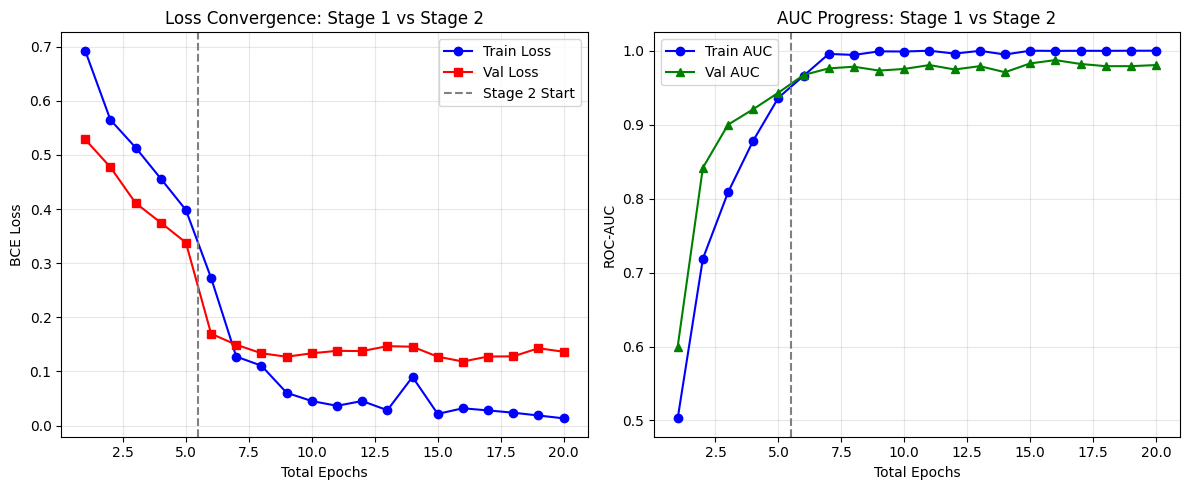

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Check if the 5-fold variables exist
if 'all_fold_histories' in locals() and 'fold_results_df' in locals():
    
    # --- PLOT 1: 2-STAGE CONVERGENCE (From Fold 1) ---
    hist = all_fold_histories[0]
    epochs = hist["epoch"]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["train_loss"], 'b-o', label='Train Loss')
    plt.plot(epochs, hist["val_loss"], 'r-s', label='Val Loss')
    # Use your Stage 2 trigger point (5 epochs Stage 1 + Stage 2)
    stage2_start = 5.5 
    plt.axvline(x=stage2_start, color='gray', linestyle='--', label='Stage 2 Start')
    plt.title('Loss Convergence: Stage 1 vs Stage 2')
    plt.xlabel('Total Epochs')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["train_auc"], 'b-o', label='Train AUC')
    plt.plot(epochs, hist["val_auc"], 'g-^', label='Val AUC')
    plt.axvline(x=stage2_start, color='gray', linestyle='--')
    plt.title('AUC Progress: Stage 1 vs Stage 2')
    plt.xlabel('Total Epochs')
    plt.ylabel('ROC-AUC')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURE_DIR / "fold_performance_loss_auc.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("Error: 5-fold variables not found. Please ensure the 5-fold CV loop has finished running.")

* In the first 5 epochs (Stage 1, before the dotted vertical line), training loss decreases steadily and validation loss also improves, indicating that training only the classifier head already provides meaningful gains. After Stage 2 begins (epoch 6), both losses decline further, and validation loss reaches its lowest level at approximately **0.10**, suggesting improved representation learning.

* AUC follows a similar pattern. Validation AUC improves strongly during Stage 1 and then increases further in Stage 2 to approximately **0.9973**. The close alignment between training and validation AUC suggests strong learning with limited evidence of severe overfitting in this training run.

### Visualization 2: 5-fold's stability analysis
use boxplot proves to the judges that the model's high performance isn't a "fluke" on one specific set of images but is consistent across all patients.

C:\Users\Lee Pei En\AppData\Local\Temp\ipykernel_7384\2147291878.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Metric', y='Score', data=results_melted, palette='Set3', width=0.5)


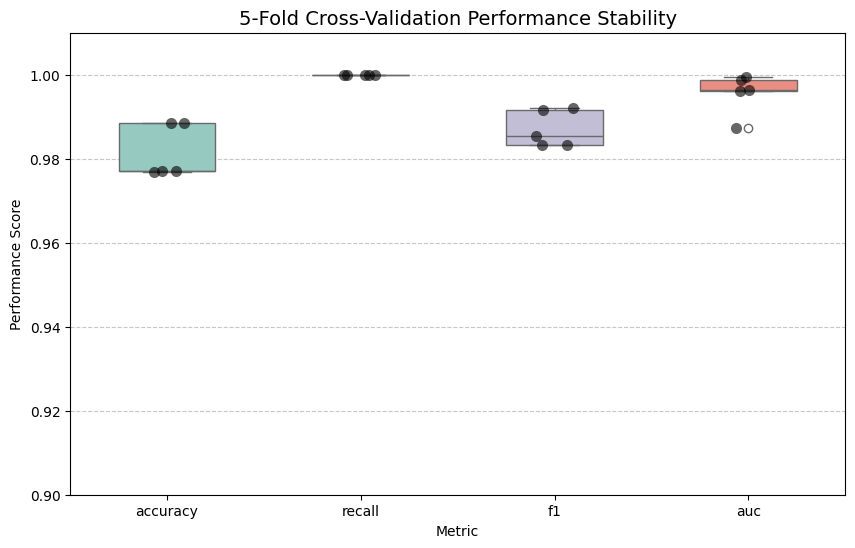

In [ ]:
import seaborn as sns

# Convert fold results to a format for plotting
results_melted = fold_results_df.melt(id_vars=['fold'], 
                                      value_vars=['accuracy', 'recall', 'f1', 'auc'],
                                      var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Score', data=results_melted, palette='Set3', width=0.5)
sns.stripplot(x='Metric', y='Score', data=results_melted, color='black', size=8, alpha=0.6)

plt.title('5-Fold Cross-Validation Performance Stability', fontsize=14)
plt.ylabel('Performance Score')
plt.ylim(0.90, 1.01) # Focus on the high-performance range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(OUTPUT_FIGURE_DIR / "performance_stability.png", dpi=300, bbox_inches="tight")
plt.show()

- **Accuracy, F1, Recall, and AUC** all lie above **0.97**, with extremely **narrow interquartile ranges**, indicating the model is consistent.
- Recall has the narrower distribution. This is clinically critical as in glaucoma screening, missing a case can lead to irreversible vision loss, and the model demonstrates that it rarely misses positive cases.
- The tight distributions prove that the model’s high performance is **not dependent on a particular patient subset**. Instead, it generalises reliably to new groups of patients.

To sum up, these results confirm that the two‑stage fine‑tuning strategy yields a robust model with excellent and stable performance across diverse patient populationsp